In [10]:
import sys
sys.path.append('./python_code')
import python_code.select_pixels as sel

In [11]:
import cv2
from imageio import imread, imsave
from matplotlib import pyplot as plt

In [12]:
# Captura de imagenes desde la camara del ordenador
capture = cv2.VideoCapture('videos/video2017-4.avi')

In [13]:
key = 0
while (key != 27):
    # Leo una imagen del video
    ret,im = capture.read()
 
    if not ret:
        print('Se acabo el video.')
        cv2.destroyAllWindows()
        break
        
    # Muestro la imagen en una ventana OpenCV
    cv2.imshow("Captura", im)

    key = cv2.waitKey(35)
print('Key:',key)

# Cierro la ventana 
cv2.destroyAllWindows() 
capture.release()


Key: 27


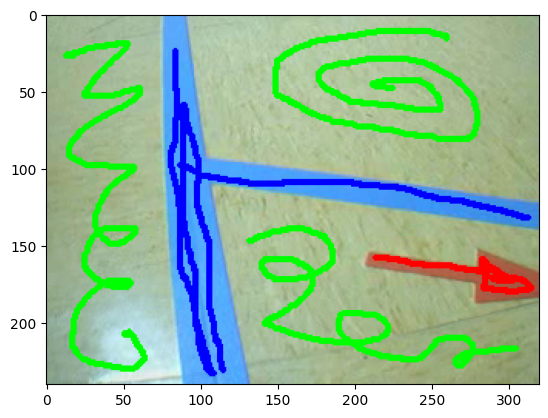

In [14]:
# Transformo la imagen al formato Python
imNumpy=cv2.cvtColor(im,cv2.COLOR_BGR2RGB)

# Llamo a la funcion para etiquetar la imagen
markImg = sel.select_fg_bg(imNumpy)

plt.imshow(markImg)
plt.show()

In [15]:
# Guardo las imagenes
imsave('001.png',imNumpy)
imsave('001_mark.png',markImg)

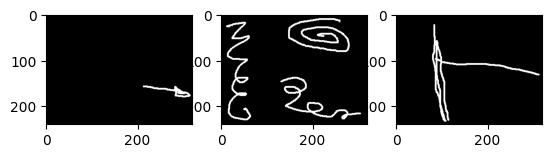

In [16]:
# Muestro los píxeles marcados de cada color.
mk = markImg[:, :, :3]
data_red = (mk[:,:,0] == 255) & (mk[:,:,1] == 0) & (mk[:,:,2] == 0)
data_blue = (mk[:,:,2] == 255) & (mk[:,:,0] == 0) & (mk[:,:,1] == 0)
data_green = (mk[:,:,1] == 255) & (mk[:,:,0] == 0) & (mk[:,:,2] == 0)

fig, axes = plt.subplots(1, 3)
axes[0].imshow(data_red, cmap='gray')
axes[1].imshow(data_green, cmap='gray')
axes[2].imshow(data_blue, cmap='gray')
plt.show()